### Phase 2: AI Similarity Engine
### Goal: Build a content-based recommender that finds "Sustainable Twins" for conventional products.

**Methodology:**
1. **Vectorization:** Convert product text into numerical vectors using **TF-IDF**.
2. **Cosine Similarity:** Calculate the "distance" between products in a high-dimensional space.
3. **The Green Nudge:** Re-rank the results to prioritize items with a high `sustainability_score`.

## 1. Data Preparation
We combine `productName`, `category`, and `details` into a single **"Style Profile"**. 
This allows the AI to understand that a "Slim Fit" shirt in the "Men's Casual" category is 
mathematically different from a "Slim Fit" dress in "Ladies' Occasionwear".

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load the "Green-Scored" 
df = pd.read_csv('../data/handm_scored.csv')

# 2. Text Preprocessing
# combined Name, Category, and Details into one "Style String"
# filled 'NaN' (empty) values with empty strings so the code doesn't crash
df['combined_features'] = (
    df['productName'].fillna('') + " " + 
    df['mainCatCode'].fillna('') + " " + 
    df['details'].fillna('')
).str.lower()

print(f"✅ Loaded {len(df)} products.")
print(f"Sample 'Style String': {df['combined_features'].iloc[0][:100]}...")

✅ Loaded 9677 products.
Sample 'Style String': derby shoes men_shoes_dressed derby shoes with open lacing at front. canvas lining and insoles. heel...


## 2. Text Vectorization (TF-IDF)
used **TF-IDF (Term Frequency-Inverse Document Frequency)** to weight our words. 
This ensures that unique style words like "linen" or "oversized" are given more importance 
than common words like "the" or "with".

In [3]:
# Initialize the Vectorizer
# 'stop_words' removes common filler words like 'and', 'the', 'is'
tfidf = TfidfVectorizer(stop_words='english')

# Create the TF-IDF Matrix (The computer's version of the style)
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

print(f"✅ Matrix Created! Shape: {tfidf_matrix.shape}")
print("This means we have 9,000+ products described by thousands of unique 'style coordinates'.")

✅ Matrix Created! Shape: (9677, 11082)
This means we have 9,000+ products described by thousands of unique 'style coordinates'.


### Cosin Similarity Mapp

creates a "Similarity Map" where every product is compared to every other product.

In [ ]:

# creates a "Similarity Map" where every product is compared to every other product.
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"✅ Similarity Map Created! Shape: {cosine_sim.shape}")

✅ Similarity Map Created! Shape: (9677, 9677)


### Recommendation Diversity

Before: The user sees 5 identical pairs of pants. (Boring/Useless)

Now: The user sees 5 different sustainable styles that are similar to the pants they liked.

In [ ]:
def get_sustainable_recommendations(product_index, num_recs=5):
    sim_scores = list(enumerate(cosine_sim[product_index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    recommended_indices = []
    seen_names = set() # Track names already recommended
    
    # Get the name of the original product to avoid recommend the same thing
    original_name = df.iloc[product_index]['productName']
    seen_names.add(original_name)

    for i, score in sim_scores[1:]:
        row = df.iloc[i]
        name = row['productName']
        
        # Diversity Check: 
        # 1. Must be Sustainable (> 70)
        # 2. Must NOT have a name already seen in this list
        if row['sustainability_score'] > 70 and name not in seen_names:
            recommended_indices.append(i)
            seen_names.add(name) # Mark this name as "used"
        
        if len(recommended_indices) >= num_recs:
            break
            
    return df.iloc[recommended_indices]

# tes by picking a product (e.g., index 0)
print(f"Original Product: {df.iloc[0]['productName']} (Score: {df.iloc[0]['sustainability_score']})")
print("-" * 30)
print("Sustainable Alternatives:")
get_sustainable_recommendations(0)[['productName', 'sustainability_score', 'materials']]

Original Product: Derby Shoes (Score: 0.0)
------------------------------
Sustainable Alternatives:


,productName,sustainability_score,materials
72,Deck Shoes,80.0,COMPOSITION\nLining:Cotton 100%\nUpper:Polyest...
83,Faux Suede Driving Shoes,80.0,COMPOSITION\nUpper:Polyester 100%\nSole:Thermo...
169,Pool Slide Shoes,80.0,"COMPOSITION\nLining:Polyester 85%, Spandex 15%..."
26,Chelsea Boots,80.0,COMPOSITION\nLining:Cotton 100%\nLining:Polyur...
140,Ankle Boots,80.0,COMPOSITION\nLining:Polyester 100%\nUpper:Poly...


### Tested The Recommender System To Recommend Top 5 Similar Items For Different Items

In [21]:
def display_recommendations(idx):
    target = df.iloc[idx]
    recs = get_sustainable_recommendations(idx)
    
    print(f"🔍 SEARCHING FOR: {target['productName'].upper()}")
    print(f"Current Sustainability Score: {target['sustainability_score']}")
    print("="*50)
    print(f"🌿 TOP 5 SUSTAINABLE ALTERNATIVES:")
    print("-" * 50)
    
    for i, row in recs.iterrows():
        print(f"✅ {row['productName']}")
        print(f"   Score: {row['sustainability_score']} | Category: {row['mainCatCode']}")
        # Show a snippet of the materials to prove why it's green
        print(f"   Key Materials: {str(row['materials'])[:70]}...") 
        print("-" * 30)

# Tested it with a different item! 
display_recommendations(250)

🔍 SEARCHING FOR: HEELED BOOTS
Current Sustainability Score: 0.0
🌿 TOP 5 SUSTAINABLE ALTERNATIVES:
--------------------------------------------------
✅ Boots
   Score: 80.0 | Category: ladies_shoes_ankle_boots
   Key Materials: COMPOSITION
Lining:Polyester 100%
Sock:Polyester 100%
Sole:Thermoplast...
------------------------------
✅ Knee-High Boots
   Score: 80.0 | Category: ladies_shoes_ankle_boots
   Key Materials: COMPOSITION
Lining:Polyester 100%
Sole:Thermoplastic rubber 100%
Upper...
------------------------------
✅ Chunky Knee-High Boots
   Score: 80.0 | Category: ladies_shoes_ankle_boots
   Key Materials: COMPOSITION
Lining:Polyester 100%
Sole:Polyester 100%
Upper:Polyuretha...
------------------------------
✅ Ankle-high Sock Boots
   Score: 80.0 | Category: ladies_shoes_ankle_boots
   Key Materials: COMPOSITION
Lining:Polyester 95%, Spandex 5%
Upper:Polyamide 50%, Poly...
------------------------------
✅ Chunky Ankle Boots
   Score: 80.0 | Category: ladies_shoes_ankle_boots
   

### Rcommender System Visuals

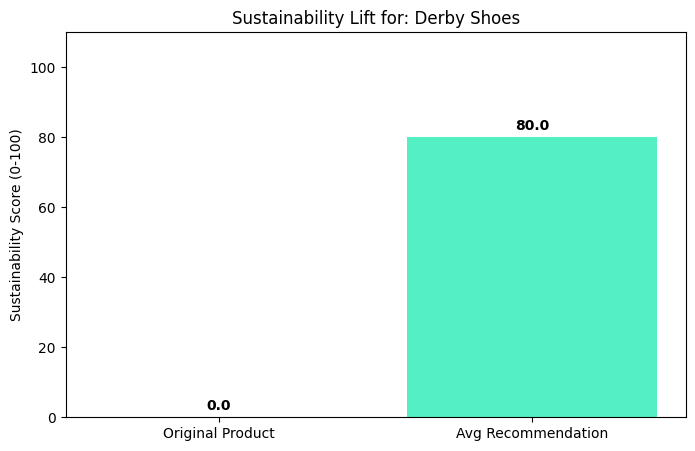

In [ ]:
import matplotlib.pyplot as plt

def plot_impact(idx):
    target_score = df.iloc[idx]['sustainability_score']
    recs = get_sustainable_recommendations(idx)
    avg_rec_score = recs['sustainability_score'].mean()
    
    plt.figure(figsize=(8, 5))
    colors = ['#ff7675', '#55efc4'] # Red for original, Green for recommendations
    
    plt.bar(['Original Product', 'Avg Recommendation'], [target_score, avg_rec_score], color=colors)
    plt.ylabel('Sustainability Score (0-100)')
    plt.title(f"Sustainability Lift for: {df.iloc[idx]['productName']}")
    plt.ylim(0, 110)
    
    # Add text labels on top of bars
    plt.text(0, target_score + 2, f"{target_score}", ha='center', fontweight='bold')
    plt.text(1, avg_rec_score + 2, f"{avg_rec_score:.1f}", ha='center', fontweight='bold')
    
    plt.show()

# Try out!
plot_impact(0) # For the Derby Shoes